# Pricnciple Component Analysis
### The note book implements the PCA on synthetic dataset
#### Last modified at 8 August 2025
#### Ibrahim Radwan

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Create a synthetic dataset
means = [2.13, -99, 0.11, -1.01] # 4 columns with different means
# Covariance matrix - generalization of the concept of variance to the multivariate case 
cov_matrix = np.array([[1, 0.96, 0, 0], [0.96, 1, 0, 0], [0, 0, 1, 0.87], [0, 0, 0.87, 1]]) 
print('Covariance matrix')
print(cov_matrix)

n = 100 # number of rows
dataset = np.random.multivariate_normal(means, cov_matrix, n)
print("\nDataset:\n", dataset)
print("\nDataset shape:\n", dataset.shape)

Covariance matrix
[[1.   0.96 0.   0.  ]
 [0.96 1.   0.   0.  ]
 [0.   0.   1.   0.87]
 [0.   0.   0.87 1.  ]]

Dataset:
 [[ 2.55198540e-02 -1.01046276e+02  1.05648531e-01 -1.25228767e+00]
 [ 1.07821853e+00 -1.00193670e+02  1.48702294e-01 -5.98441714e-01]
 [ 1.66249502e+00 -9.97489558e+01  8.61347266e-01 -9.95376447e-01]
 [ 4.82164686e+00 -9.64275320e+01  1.40605835e+00  2.30030890e-01]
 [ 2.56957203e+00 -9.83422152e+01  6.36252849e-01 -3.36557684e-02]
 [ 2.06769503e+00 -9.91775124e+01  8.19089396e-01 -4.11396615e-01]
 [ 4.02016071e+00 -9.73256707e+01  8.48965702e-01  4.18753516e-01]
 [ 9.41554034e-01 -1.00746614e+02 -4.44622745e-01 -1.90511372e+00]
 [ 1.02903563e+00 -1.00099368e+02 -2.14841087e+00 -3.08927378e+00]
 [ 1.62982715e+00 -9.93862529e+01 -6.82139886e-01 -2.30923575e-01]
 [ 1.99115999e+00 -9.91877600e+01  6.70211919e-01 -2.56018578e-01]
 [ 1.44852469e+00 -9.95325740e+01  2.12697477e+00  1.58238414e+00]
 [ 3.67552792e+00 -9.73567015e+01 -1.90386435e-01 -9.66754272e-01]
 [ 3.23

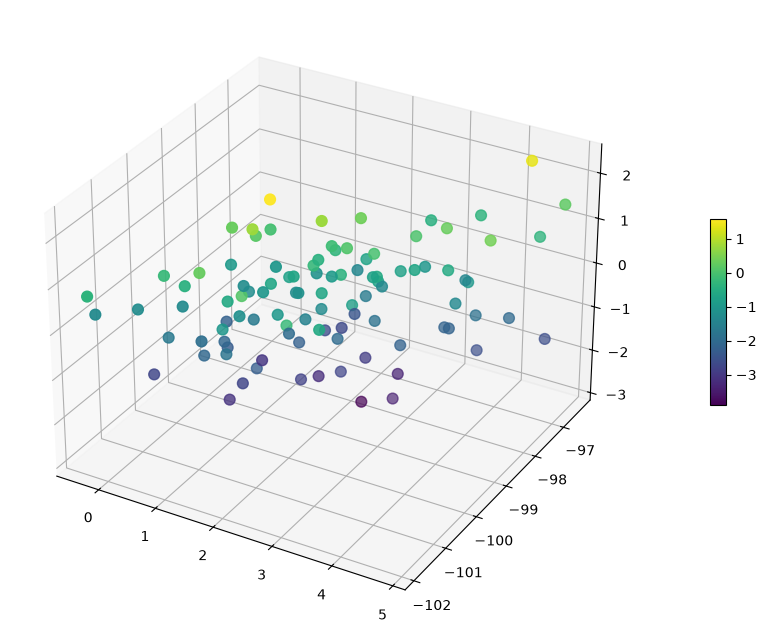

In [3]:
# Let us plot the data
fig = plt.figure(figsize=(8, 16))
ax = fig.add_subplot(111, projection='3d')
img = ax.scatter(xs=dataset[:,0], ys=dataset[:,1], zs=dataset[:,2], c=dataset[:,3], s=60)

cax = fig.add_axes([ax.get_position().x1+0.10, ax.get_position().y0+0.14, 0.02,
                    ax.get_position().height*0.3])
fig.colorbar(img, cax=cax)

plt.show()

### 1. Data standardization

In [4]:
print('Before standardization')
print('Mean:\n',dataset.mean(axis=0))
print('Standard deviation:\n',dataset.std(axis=0))

# Standardization
dataset_standardizated = (dataset - np.mean(dataset, axis=0)) / np.std(dataset, axis=0)

print('\nAfter standardization')
print('Mean:\n',dataset_standardizated.mean(axis=0))
print('Standard deviation:\n',dataset_standardizated.std(axis=0))

Before standardization
Mean:
 [  2.09284636 -99.02444767  -0.11258056  -1.18848749]
Standard deviation:
 [1.11420073 1.14051501 1.0746304  1.10861762]

After standardization
Mean:
 [-4.46309656e-16  7.46624984e-15  3.77475828e-17  2.42028619e-16]
Standard deviation:
 [1. 1. 1. 1.]


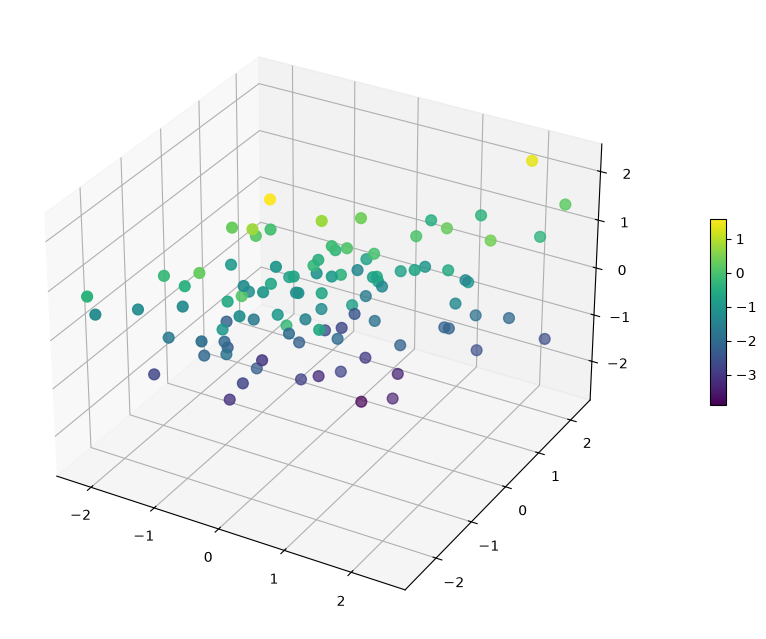

In [5]:
# Let us plot the standardised data
fig = plt.figure(figsize=(8, 16))
ax = fig.add_subplot(111, projection='3d')
img = ax.scatter(xs=dataset_standardizated[:,0], ys=dataset_standardizated[:,1], zs=dataset_standardizated[:,2], c=dataset[:,3], s=60)

cax = fig.add_axes([ax.get_position().x1+0.10, ax.get_position().y0+0.14, 0.02,
                    ax.get_position().height*0.3])
fig.colorbar(img, cax=cax)

plt.show()

### 2. Creating a covariance matrix.

In [6]:
covariance_matrix = np.cov(dataset_standardizated.T)
covariance_matrix

array([[ 1.01010101,  0.9846616 ,  0.02872881,  0.0587607 ],
       [ 0.9846616 ,  1.01010101, -0.01136854,  0.0267713 ],
       [ 0.02872881, -0.01136854,  1.01010101,  0.94284137],
       [ 0.0587607 ,  0.0267713 ,  0.94284137,  1.01010101]])

### 3. Eigen Decomposition.

In [7]:
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
print('eigenvalues:\n',eigenvalues,'\n\neigenvectors:\n',eigenvectors)

eigenvalues:
 [2.02999399 1.9189884  0.02437988 0.06704177] 

eigenvectors:
 [[-0.59352755 -0.38369156 -0.70296497 -0.07966234]
 [-0.57936844 -0.40604796  0.70460388  0.05468665]
 [-0.38470371  0.59372272  0.08032048 -0.70217164]
 [-0.40504359  0.57913657 -0.0540578   0.70542064]]


### 4. Explained total variance.

[np.float64(0.502), np.float64(0.475), np.float64(0.017), np.float64(0.006)]


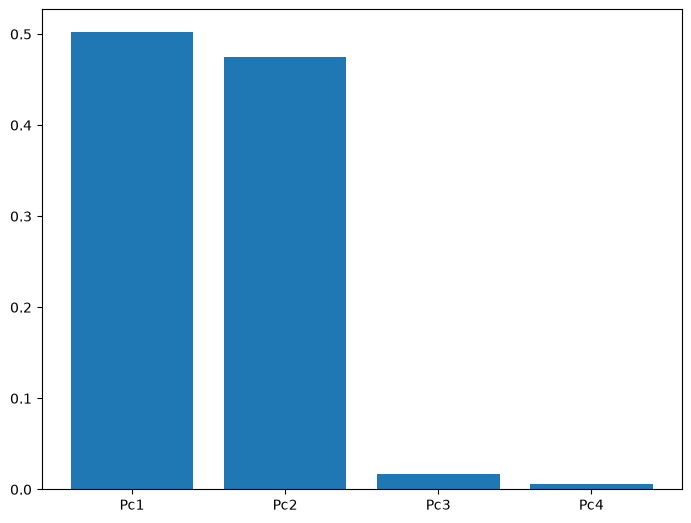

In [8]:
explained_variance = [round((i/np.sum(eigenvalues)), 3) for i in sorted(eigenvalues, reverse=True)]
print(explained_variance)
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
x_axis_labels = ['Pc1', 'Pc2', 'Pc3', 'Pc4']
ax.bar(x_axis_labels,explained_variance)
plt.show()

### 5. Feature transformation.

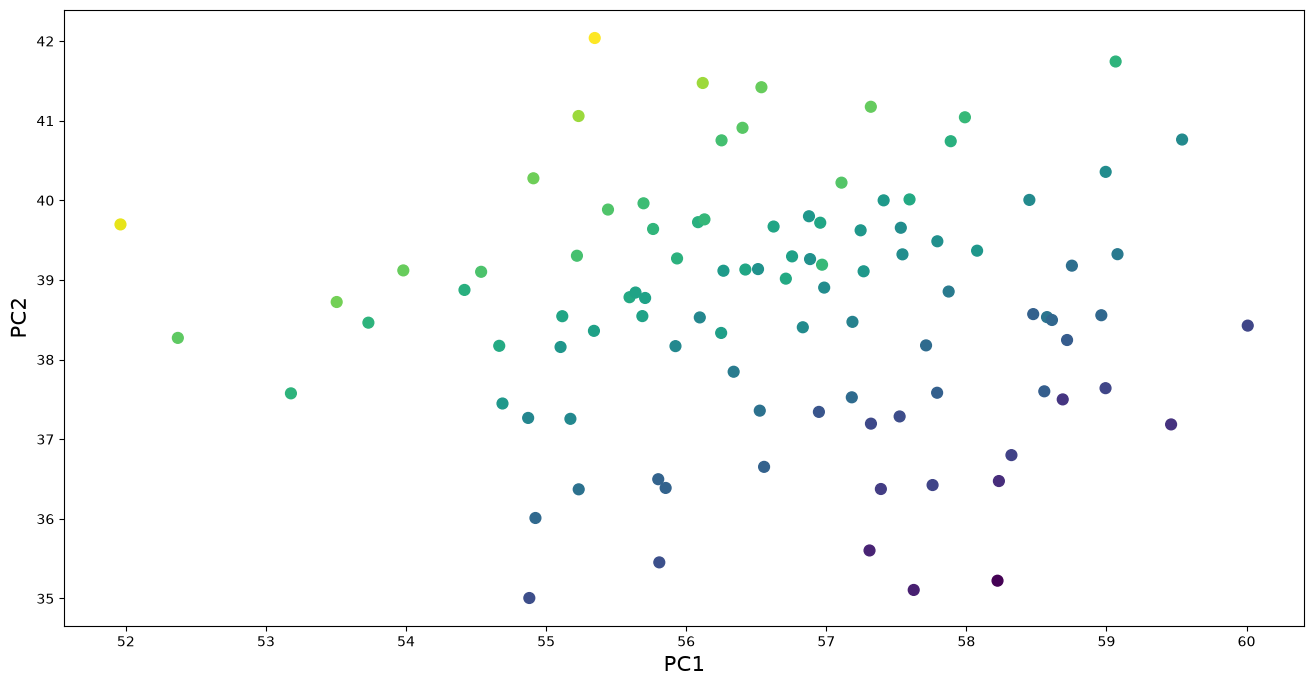

In [9]:
eigenpairs = [(np.abs(eigenvalues[i]), eigenvectors[:, i]) for i in range(len(eigenvalues))]
eigenpairs.sort(key = lambda k: k[0], reverse=True)

eigenpairs

eigenpairs[0][1]

w = np.hstack((eigenpairs[0][1][:, np.newaxis],
               eigenpairs[1][1][:, np.newaxis]))
pc1 = dataset.dot(w.T[0])
pc2 = dataset.dot(w.T[1])

fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(111)
ax.scatter(x=pc1, y=pc2, c=dataset[:,3], s=60)
ax.set_xlabel(xlabel='PC1', rotation=0, loc='center', size=15)
ax.set_ylabel(ylabel='PC2', rotation=90, loc='center', size=15)
plt.show()
